# Chapter 23 · Grafana + Prometheus: walkthrough

Companion to `notes/23_grafana.html` (video 11:08:48 – end).

The video launches an EC2 instance, installs Docker, runs **Grafana** and **Prometheus** as containers, opens ports
3000 and 9090, connects Grafana to Prometheus and builds a dashboard from Prometheus's own metrics.

This notebook runs the same three processes **locally**, with one important addition: the thing being monitored is
our own **Chapter 17 sentiment API**, so the dashboards show real application and model metrics instead of
Prometheus watching itself.

| Part | What happens |
|---|---|
| 1 | instrument the API: `/metrics`, and the four metric types |
| 2 | Prometheus: `prometheus.yml`, scrape targets, the pull model |
| 3 | generate traffic: baseline → spike → errors → **drift** → recovery |
| 4 | PromQL: ask Prometheus the questions a dashboard asks |
| 5 | alert rules, and what fired |
| 6 | Grafana: provisioned data source + dashboard, and a screenshot of it with live data |
| 7 | what to monitor for an ML system (the part the video only hints at) |
| 8 | shut everything down |

**Downloads:** Prometheus (~100 MB) and Grafana (~450 MB) are fetched once into `~/.cache/mlops-course-tools`.
Delete that folder when you're done with the chapter.

In [1]:
import json, subprocess, shutil, sys, time, urllib.parse, urllib.request
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt, matplotlib.dates as mdates
from IPython.display import Image, display

HERE = Path.cwd()
assert (HERE / "stack.py").exists(), "run this notebook from projects/ch23_grafana"
sys.path.insert(0, str(HERE))
import importlib, stack, traffic
importlib.reload(stack); importlib.reload(traffic)
REPORTS = HERE / "reports"; REPORTS.mkdir(exist_ok=True)
pd.set_option("display.max_colwidth", 100); pd.set_option("display.width", 200)

print("docker:", shutil.which("docker") or "not installed — running the binaries directly instead")
PROM_DIR, GRAFANA_DIR = stack.ensure_tools()
print("prometheus:", PROM_DIR, "\ngrafana   :", GRAFANA_DIR)

docker: not installed — running the binaries directly instead
prometheus: /Users/hemanthreddy/.cache/mlops-course-tools/prometheus 
grafana   : /Users/hemanthreddy/.cache/mlops-course-tools/grafana


## 1 · Instrument the application
This is the step the video skips, and it's the one that matters: **Prometheus can only scrape metrics that your
application exposes.** The video's dashboard shows Prometheus's own `/metrics`, which says nothing about a model.

`instrumented_api.py` wraps the Chapter 17 Flask API and adds a `/metrics` endpoint with:

| Metric type | Example here | Use it for |
|---|---|---|
| **Counter** (only goes up) | `http_requests_total`, `model_predictions_total{label}` | totals; take `rate()` for per-second values |
| **Gauge** (up and down) | `http_requests_in_flight`, `model_info` | current values: queue depth, temperature, version |
| **Histogram** (buckets) | `http_request_duration_seconds`, `model_batch_size` | latency and size distributions → `histogram_quantile()` for p95 |
| **Summary** (client-side quantiles) | not used | rarely: histograms aggregate across instances, summaries don't |

In [2]:
stack.start_api()
time.sleep(1)
body = json.dumps({"comments": ["great explanation, thanks", "worst tutorial ever", "where is the dataset"]}).encode()
req = urllib.request.Request(f"http://127.0.0.1:{stack.API_PORT}/predict", data=body,
                             headers={"Content-Type": "application/json"})
print(json.dumps(json.load(urllib.request.urlopen(req)), indent=1)[:260], "…")

API        http://127.0.0.1:5002        ready


[
 {
  "comment": "great explanation, thanks",
  "label": "positive",
  "sentiment": 1
 },
 {
  "comment": "worst tutorial ever",
  "label": "negative",
  "sentiment": -1
 },
 {
  "comment": "where is the dataset",
  "label": "neutral",
  "sentiment": 0
 }
] …


In [3]:
metrics_text = urllib.request.urlopen(f"http://127.0.0.1:{stack.API_PORT}/metrics").read().decode()
keep = ("http_requests_total", "model_predictions_total", "http_request_duration_seconds_bucket",
        "http_request_duration_seconds_count", "http_requests_in_flight", "model_info", "model_batch_size_sum")
print("\n".join(l for l in metrics_text.splitlines()
                if l.startswith(keep) or (l.startswith("# HELP") and any(k in l for k in keep)))[:1600])

# HELP http_requests_total HTTP requests
http_requests_total{endpoint="/",method="GET",status="200"} 1.0
http_requests_total{endpoint="/predict",method="POST",status="200"} 1.0
# HELP model_predictions_total Predictions returned, by label
model_predictions_total{label="positive"} 1.0
model_predictions_total{label="negative"} 1.0
model_predictions_total{label="neutral"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.01"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.025"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.05"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.1"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.25"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="0.5"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="1.0"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="2.5"} 1.0
http_request_duration_seconds_bucket{endpoint="/",le="5.0"} 1.0
http_request_duration_seconds_bucket{endpoi

That plain-text page is the whole contract: no agent, no push, no SDK — just numbers with labels over HTTP.
Labels (`endpoint`, `status`, `label`) are what let you slice the same counter many ways later.

## 2 · Prometheus: scrape, store, evaluate

In [4]:
print((HERE / "prometheus.yml").read_text())

# Prometheus scrapes targets over HTTP and stores the samples in its own time-series database.
# Grafana never talks to your app — it asks Prometheus.
global:
  scrape_interval: 5s          # production default is 15s–60s; 5s here so the demo shows detail
  evaluation_interval: 5s

rule_files:
  - alerts.yml               # alert rules are evaluated by Prometheus, not by Grafana

scrape_configs:
  - job_name: sentiment-api    # the Chapter 17 model API, instrumented with prometheus_client
    static_configs:
      - targets: ["127.0.0.1:5002"]
        labels: { service: "yt-sentiment", env: "demo" }

  - job_name: prometheus       # Prometheus scraping itself — the only job the video ever uses
    static_configs:
      - targets: ["127.0.0.1:9090"]

# In production, firing alerts are sent to Alertmanager, which handles grouping, silences and routing
# to Slack/PagerDuty/email. Grafana can also own alerting; pick one and stick to it.



In [5]:
stack.start_prometheus(PROM_DIR)
time.sleep(8)          # let it scrape a couple of times
targets = json.load(urllib.request.urlopen(f"http://127.0.0.1:{stack.PROM_PORT}/api/v1/targets"))["data"]["activeTargets"]
pd.DataFrame([{"job": t["labels"]["job"], "target": t["scrapeUrl"], "health": t["health"],
               "last scrape": t["lastScrape"][11:19]} for t in targets])

Prometheus http://127.0.0.1:9090        ready


,job,target,health,last scrape
0,prometheus,http://127.0.0.1:9090/metrics,up,14:22:01
1,sentiment-api,http://127.0.0.1:5002/metrics,up,14:22:00


Prometheus **pulls**: it asks each target for `/metrics` every `scrape_interval`. That's why a target must be
reachable from Prometheus (a security-group rule in the video's EC2 setup), and why short-lived jobs need a
separate Pushgateway.

## 3 · Generate traffic
Five phases so the graphs have something to say. Watch for the **drift** phase: the incoming comments turn
negative, the code and the model stay exactly the same, and only the *prediction mix* moves.

In [6]:
t0 = time.time()
marks = traffic.run(scale=1.0)
t1 = time.time()
print(f"\ntotal {t1 - t0:.0f}s of traffic")
time.sleep(8)          # one last scrape so the final phase lands in the database

  14:22:01  baseline  2 rps for 60s


  14:23:03  spike     12 rps for 45s


  14:23:48  errors    4 rps for 30s  (35% malformed requests)


  14:24:19  drift     3 rps for 75s  (comments turn negative)


  14:25:35  recovery  2 rps for 30s



total 245s of traffic


## 4 · PromQL: the questions a dashboard asks
A dashboard panel is just a query. These are the same expressions used in the Grafana dashboard below.

In [7]:
PROM = f"http://127.0.0.1:{stack.PROM_PORT}"

def query_range(expr, start, end, step=5):
    url = (f"{PROM}/api/v1/query_range?query={urllib.parse.quote(expr)}"
           f"&start={start}&end={end}&step={step}")
    data = json.load(urllib.request.urlopen(url))["data"]["result"]
    out = {}
    for series in data:
        name = ", ".join(f"{v}" for k, v in series["metric"].items() if k != "__name__") or "value"
        s = pd.Series({pd.Timestamp(float(t), unit="s"): float(v) for t, v in series["values"]})
        out[name] = s
    return pd.DataFrame(out).sort_index()

def query(expr):
    url = f"{PROM}/api/v1/query?query={urllib.parse.quote(expr)}"
    return json.load(urllib.request.urlopen(url))["data"]["result"]

print("requests served :", round(sum(float(r['value'][1]) for r in query('sum(http_requests_total)')), 0))
print("predictions made:", round(sum(float(r['value'][1]) for r in query('sum(model_predictions_total)')), 0))
for r in query('sum by (label) (model_predictions_total)'):
    print(f"   {r['metric']['label']:<9}{float(r['value'][1]):>8.0f}")

requests served : 1057.0
predictions made: 9867.0
   positive     2263
   negative      324
   neutral      7280


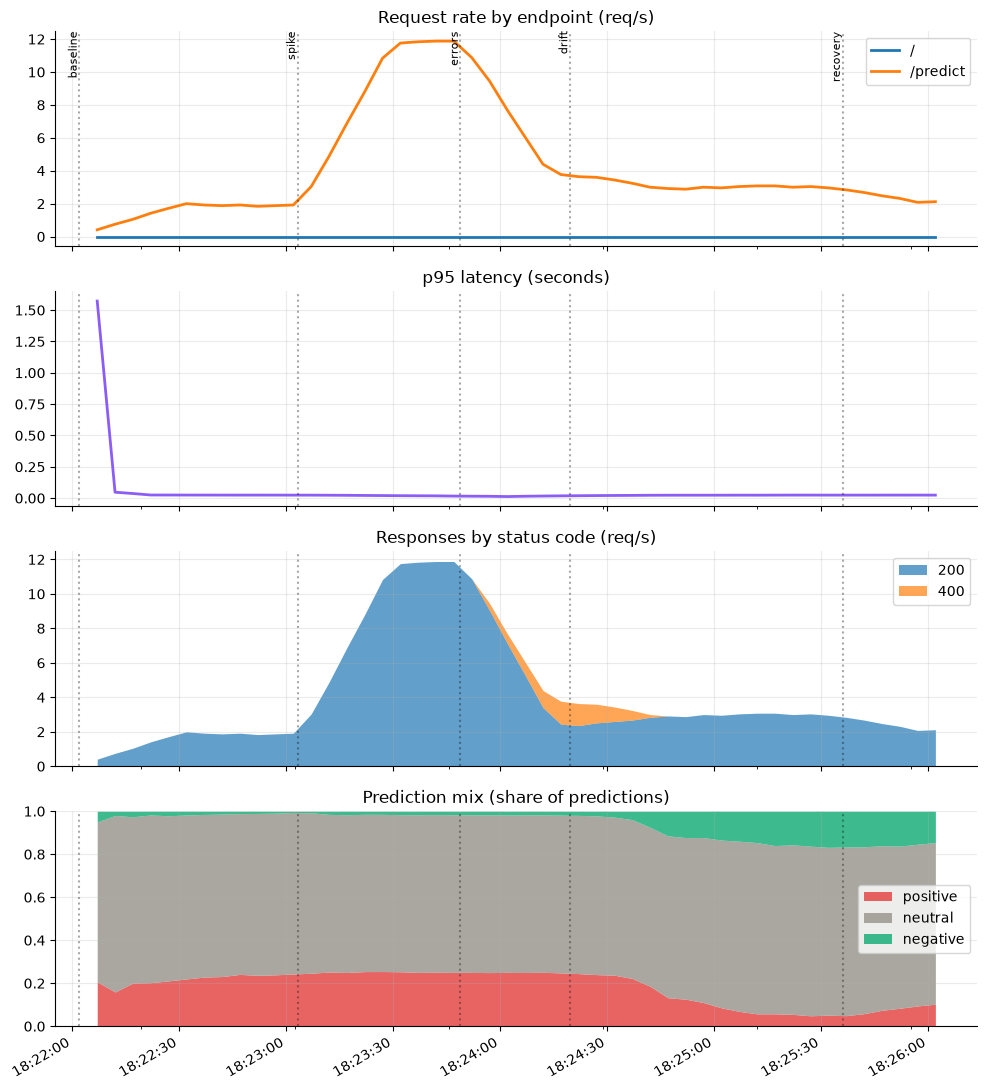

In [8]:
rate_by_endpoint = query_range("sum by (endpoint) (rate(http_requests_total[30s]))", t0, t1)
latency = query_range("histogram_quantile(0.95, sum by (le) (rate(http_request_duration_seconds_bucket[1m])))", t0, t1)
by_status = query_range("sum by (status) (rate(http_requests_total[30s]))", t0, t1)
mix = query_range("sum by (label) (rate(model_predictions_total[1m])) "
                  "/ ignoring(label) group_left sum(rate(model_predictions_total[1m]))", t0, t1)

fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
rate_by_endpoint.plot(ax=axes[0], linewidth=2); axes[0].set_title("Request rate by endpoint (req/s)")
latency.plot(ax=axes[1], linewidth=2, color="#8b5cf6", legend=False); axes[1].set_title("p95 latency (seconds)")
by_status.plot.area(ax=axes[2], linewidth=0, alpha=.7); axes[2].set_title("Responses by status code (req/s)")
colors = {"positive": "#1baf7a", "neutral": "#9a9890", "negative": "#e34948"}
mix[[c for c in ["positive", "neutral", "negative"] if c in mix]].plot.area(
    ax=axes[3], color=[colors[c] for c in mix.columns if c in colors], linewidth=0, alpha=.85)
axes[3].set_title("Prediction mix (share of predictions)"); axes[3].set_ylim(0, 1)
for name, when in marks[:-1]:
    for ax in axes:
        ax.axvline(pd.Timestamp(when, unit="s"), color="#0b0b0b", alpha=.35, linestyle=":")
    axes[0].annotate(name, (pd.Timestamp(when, unit="s"), axes[0].get_ylim()[1]),
                     fontsize=8, rotation=90, va="top", ha="right")
for ax in axes:
    ax.grid(alpha=.25)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.tight_layout(); plt.savefig(REPORTS / "ch23_promql.png", dpi=110); plt.show()

Read the bottom panel: during **drift** the negative share climbs even though nothing was deployed. That is the
signal a model owner cares about, and it is invisible in CPU or latency graphs.

The top three panels are the classic service signals (traffic, latency, errors) — the "RED method": **R**ate,
**E**rrors, **D**uration.

## 5 · Alerts live with the data, not the dashboard
`alerts.yml` is evaluated by Prometheus every few seconds. Grafana can alert too; pick one place and stick to it.

In [9]:
print((HERE / "alerts.yml").read_text()[:900])
rules = json.load(urllib.request.urlopen(f"{PROM}/api/v1/rules"))["data"]["groups"]
rows = [{"alert": r["name"], "state": r["state"], "for": r["duration"],
         "firing now": len(r.get("alerts", []))}
        for g in rules for r in g["rules"] if r["type"] == "alerting"]
pd.DataFrame(rows)

# Alerting lives with the data, not with the dashboard: Prometheus evaluates these expressions every
# `evaluation_interval` and marks an alert as firing once the condition holds for `for:`.
groups:
  - name: sentiment-api
    rules:
      - alert: HighErrorRate
        expr: sum(rate(http_requests_total{status!~"2.."}[1m])) > 0.05
        for: 30s
        labels: { severity: warning }
        annotations:
          summary: "The API is returning errors ({{ $value | printf \"%.2f\" }} per second)"

      - alert: SlowResponses
        expr: histogram_quantile(0.95, sum by (le) (rate(http_request_duration_seconds_bucket[2m]))) > 1
        for: 1m
        labels: { severity: warning }
        annotations:
          summary: "p95 latency is above 1s"

      - alert: NegativeSentimentSurge
        expr: |
          sum(rate(model_predictions_total{label="negative"}[2m]))
            / sum(ra


,alert,state,for,firing now
0,HighErrorRate,inactive,30,0
1,SlowResponses,inactive,60,0
2,NegativeSentimentSurge,inactive,60,0


In [10]:
# ALERTS is a real series, so you can graph when an alert was firing
fired = query_range('ALERTS{alertstate="firing"}', t0, t1)
if len(fired.columns):
    print("alerts that fired during the run:")
    for c in fired.columns: print("   ", c)
else:
    print("no alert fired in this window (the run may have been too short for the `for:` clause)")

alerts that fired during the run:
    HighErrorRate, firing, warning


## 6 · Grafana
The video does this by hand: log in with admin/admin, add the Prometheus data source, paste the URL, Save & test,
then build panels. Here the same configuration is **provisioned from files**, so a fresh Grafana comes up ready —
which is how you'd keep dashboards in git.

In [11]:
print((HERE / "grafana" / "provisioning" / "datasources" / "prometheus.yml").read_text())
dash = json.loads((HERE / "grafana" / "dashboards" / "mlops.json").read_text())
pd.DataFrame([{"panel": p["title"], "type": p["type"],
               "query": p["targets"][0]["expr"][:78] + ("…" if len(p["targets"][0]["expr"]) > 78 else "")}
              for p in dash["panels"]])

# Provisioning: the same thing the video does by hand in Connections → Data sources → Prometheus → URL → Save & test.
# Keeping it as a file means a new Grafana comes up already configured.
apiVersion: 1
datasources:
  - name: Prometheus
    type: prometheus
    uid: prom-mlops
    access: proxy
    url: http://127.0.0.1:9090
    isDefault: true
    jsonData:
      timeInterval: 5s



,panel,type,query
0,Requests / second,stat,sum(rate(http_requests_total[1m]))
1,p95 latency,stat,"histogram_quantile(0.95, sum by (le) (rate(http_request_duration_seconds_bucke…"
2,Errors (non-2xx) / second,stat,"sum(rate(http_requests_total{status!~""2..""}[1m]))"
3,In flight now,stat,sum(http_requests_in_flight)
4,Request rate by endpoint,timeseries,sum by (endpoint) (rate(http_requests_total[30s]))
5,Latency percentiles (from the histogram),timeseries,"histogram_quantile(0.50, sum by (le) (rate(http_request_duration_seconds_bucke…"
6,Prediction mix — the ML-specific signal,timeseries,sum by (label) (rate(model_predictions_total[1m])) / ignoring(label) group_lef…
7,Responses by status code,timeseries,sum by (status) (rate(http_requests_total[30s]))


In [12]:
stack.start_grafana(GRAFANA_DIR)
time.sleep(6)
health = json.load(urllib.request.urlopen(f"http://127.0.0.1:{stack.GRAFANA_PORT}/api/health"))
ds = json.load(urllib.request.urlopen(f"http://127.0.0.1:{stack.GRAFANA_PORT}/api/datasources"))
found = json.load(urllib.request.urlopen(f"http://127.0.0.1:{stack.GRAFANA_PORT}/api/search?type=dash-db"))
print("grafana        :", health["version"])
print("data source    :", ds[0]["name"], "→", ds[0]["url"], "(provisioned, no clicking)")
print("dashboard      :", found[0]["title"], "→", found[0]["url"])

Grafana    http://127.0.0.1:3000        ready


grafana        : 13.2.2
data source    : Prometheus → http://127.0.0.1:9090 (provisioned, no clicking)
dashboard      : Sentiment API · service and model → /d/mlops-api/sentiment-api-c2b7-service-and-model


saved ch23_grafana_dashboard.png (80 KB)


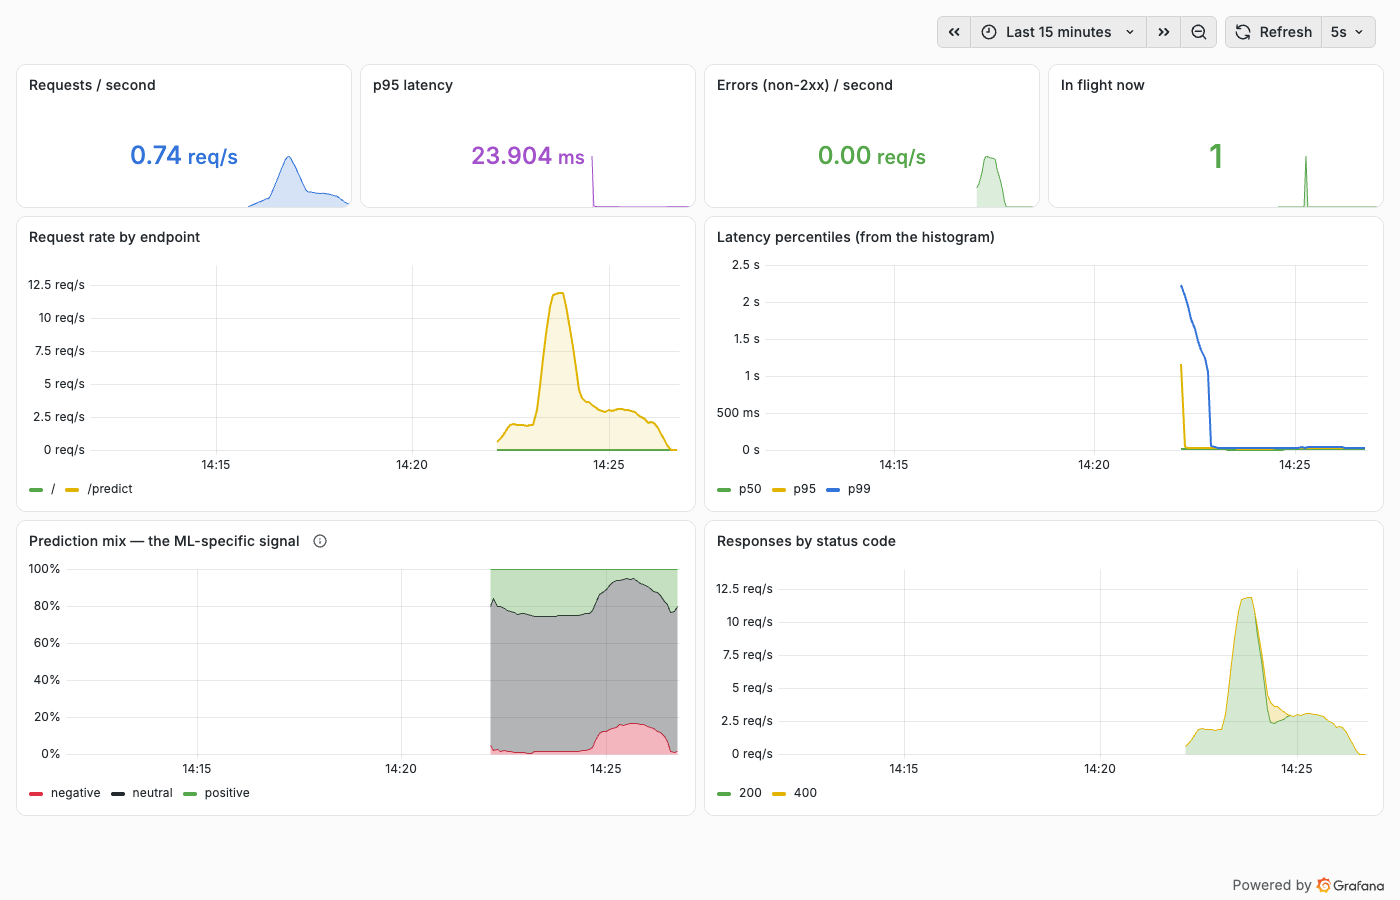

In [13]:
# screenshot the live dashboard with headless Chrome (kiosk mode hides the navigation)
CHROME = "/Applications/Google Chrome.app/Contents/MacOS/Google Chrome"
shot = REPORTS / "ch23_grafana_dashboard.png"
url = (f"http://127.0.0.1:{stack.GRAFANA_PORT}{found[0]['url']}"
       f"?kiosk&from=now-15m&to=now&theme=light")
if Path(CHROME).exists():
    shot.unlink(missing_ok=True)
    # headless Chrome writes the PNG but can linger, so don't wait on the process: poll for the file
    chrome = subprocess.Popen([CHROME, "--headless=new", f"--user-data-dir={HERE / '.runtime' / 'chrome'}",
                               "--hide-scrollbars", "--window-size=1400,900", "--virtual-time-budget=25000",
                               f"--screenshot={shot}", url],
                              stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    for _ in range(90):
        time.sleep(1)
        if shot.exists() and shot.stat().st_size > 20_000:
            time.sleep(2)
            break
    chrome.terminate()
    print("saved", shot.name, f"({shot.stat().st_size // 1024} KB)" if shot.exists() else "— screenshot failed")
    if shot.exists():
        display(Image(str(shot), width=940))
else:
    print("Chrome not found — open this URL yourself:", url)

The panels are the PromQL queries from part 4, drawn by Grafana against the same Prometheus. Nothing here knows
anything about the model except what the API chose to expose.

## 7 · What to monitor for an ML system
The video shows CPU-style metrics and then makes the right point in passing: *save your predictions and watch them,
so you can tell whether the model is going wrong.* Four layers are worth separating:

In [14]:
layers = pd.DataFrame([
    ("Infrastructure", "CPU, memory, disk, GPU, restarts", "node_exporter / cAdvisor / cloud metrics",
     "the video's Prometheus self-metrics live here"),
    ("Service (RED)", "request rate, error rate, latency p50/p95/p99", "prometheus_client in the app",
     "our http_* metrics"),
    ("Data", "schema changes, missing values, out-of-range inputs, input drift", "validation in the pipeline; Evidently / Great Expectations",
     "compute in a job, export as metrics"),
    ("Model", "prediction distribution, confidence, ground-truth accuracy once labels arrive", "counters per label + a delayed evaluation job",
     "our model_predictions_total{label}"),
], columns=["layer", "what you watch", "where it comes from", "in this project"])
layers

,layer,what you watch,where it comes from,in this project
0,Infrastructure,"CPU, memory, disk, GPU, restarts",node_exporter / cAdvisor / cloud metrics,the video's Prometheus self-metrics live here
1,Service (RED),"request rate, error rate, latency p50/p95/p99",prometheus_client in the app,our http_* metrics
2,Data,"schema changes, missing values, out-of-range inputs, input drift",validation in the pipeline; Evidently / Great Expectations,"compute in a job, export as metrics"
3,Model,"prediction distribution, confidence, ground-truth accuracy once labels arrive",counters per label + a delayed evaluation job,our model_predictions_total{label}


A practical rule: **anything you would page someone about belongs in an alert; everything else is a dashboard.**
Ground-truth accuracy usually arrives late (hours or days), so the fast signals are the prediction mix, the input
statistics and the service metrics — which is exactly what the drift phase demonstrated.

## 8 · Shut everything down
The video's equivalent is terminating the EC2 instance so it stops charging.

In [15]:
stack.stop_all()
print("\nleft on disk:")
print(f"  {stack.RUNTIME}  (Prometheus TSDB + Grafana database for this run — safe to delete)")
print(f"  {stack.TOOLS}  (the downloaded binaries, ~1.5 GB — delete when you're done with the chapter)")
print("\n  rm -rf", stack.RUNTIME)
print("  rm -rf", stack.TOOLS)

stopped api
stopped prometheus


stopped grafana

left on disk:
  /Users/hemanthreddy/Desktop/data_science/MLOps/projects/ch23_grafana/.runtime  (Prometheus TSDB + Grafana database for this run — safe to delete)
  /Users/hemanthreddy/.cache/mlops-course-tools  (the downloaded binaries, ~1.5 GB — delete when you're done with the chapter)

  rm -rf /Users/hemanthreddy/Desktop/data_science/MLOps/projects/ch23_grafana/.runtime
  rm -rf /Users/hemanthreddy/.cache/mlops-course-tools
